# Plots for Phase Transitions

In [3]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

## Second Order Phase Transition

In [39]:
def V(phi, T):
    return 0.5*(c*T**2-mu**2)*phi**2 + l/4*phi**4

def vev(T):
    root = np.where(mu**2-c*T**2>=0, mu**2-c*T**2, 0.0)
    return np.sqrt(root/l)

In [61]:
np.linspace(0,200,11)[::-1]

array([200., 180., 160., 140., 120., 100.,  80.,  60.,  40.,  20.,   0.])

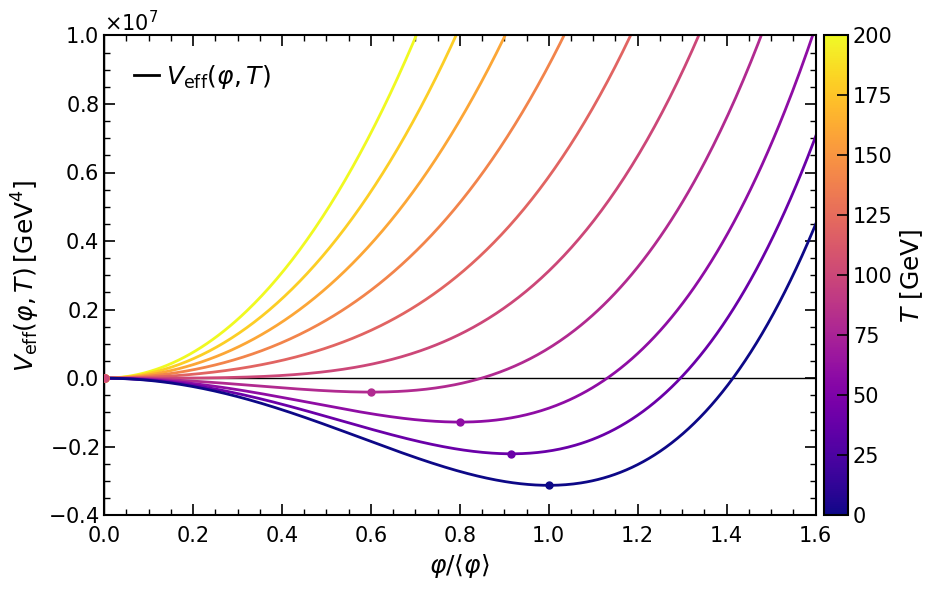

In [62]:
mu = 50
c = 0.25
l = 0.5

Tc = mu/np.sqrt(c)

phi_vals = np.linspace(-150,150, 1000)
T_vals   = np.array([200., 180., 160., 140., 120., 100.,  80.,  60.,  40.,   0.])

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.71, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    color = cmap(norm(T))
    Veff  = V(phi_vals, T)
    ax.plot(phi_vals/vev(0), Veff, label=r'$V_{\mathrm{eff}}(\varphi , T)$', color=color, lw=2, ls='-')

    mask = phi_vals > 0
    idx  = np.argmin(Veff[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = Veff[mask][idx]
    ax.plot(phi_min/vev(0), V_min, 'o', color=color, ms=5, zorder=10)

ax.set_xlim(0, 1.6)
ax.set_ylim(-4e6, 10e6)

ax.set_xlabel(r'$\varphi / \langle\varphi\rangle$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi, T) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=8)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

handles_list = [mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=1, label=r"$V_{\mathrm{eff}}(\varphi , T)$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"SOPT.pdf", format="pdf", bbox_inches="tight")
plt.show()

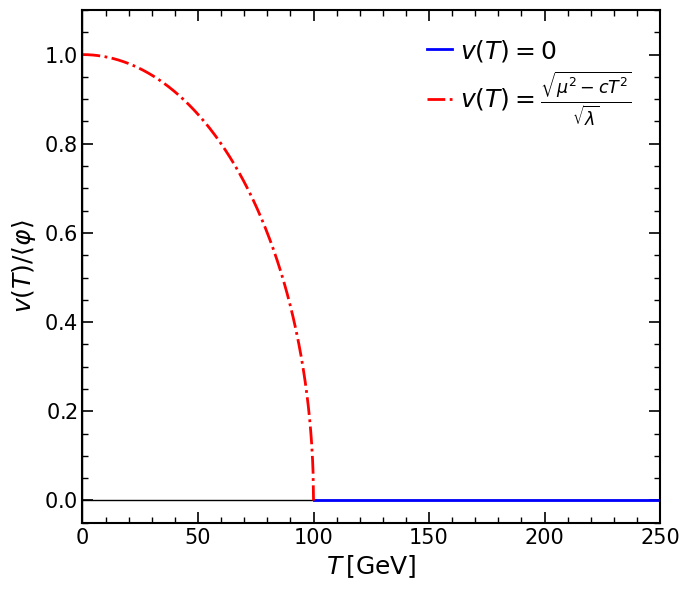

In [60]:
T_vals_Broken = np.linspace(0,100,500)
T_vals_sym = np.linspace(100,300,500)
vevs_Broken   = vev(T_vals_Broken)
vevs_sym   = vev(T_vals_sym)

fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(T_vals_sym, vevs_sym/vev(0), label=r'$v(T)=0$', lw=2, color='b', ls='-')
ax.plot(T_vals_Broken, vevs_Broken/vev(0), label=r'$v(T)=\frac{\sqrt{\mu ^2-c T^2}}{\sqrt{\lambda}}$', lw=2, color='r', ls='-.')

ax.set_xlim(0, 250)
ax.set_ylim(-0.05, 1.1)

ax.set_xlabel(r'$T \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$v(T)/\langle\varphi\rangle$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
#ax.tick_params(axis='x', which='major', pad=8)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"SOPT_VEV.pdf", format="pdf", bbox_inches="tight")
plt.show()

## First-Order Phase Transition

In [4]:
mu = 50
c = 25/64
l = 3125/10368
B = 625/3456

T0 = mu/np.sqrt(c)
Tc = mu/np.sqrt(c-(2*B**2)/l)
T1 = (2*mu*np.sqrt(l))/(np.sqrt(4*c*l-9*B**2))
xi = 2*B/l
vc = xi*Tc
v0 = mu/np.sqrt(l)

In [5]:
print(xi, T1, Tc, T0, vc, v0)

1.2 130.6394529484362 120.00000000000001 80.0 144.0 91.07359661284933


In [6]:
def V(phi, T):
    return 0.5*(c*T**2-mu**2)*phi**2 + l/4*phi**4 - B*T*phi**3

def vev(T):
    root = np.where(9*B**2*T**2-4*c*l*T**2+4*l*mu**2>=0, 9*B**2*T**2-4*c*l*T**2+4*l*mu**2, 0.0)
    phi  = (3*B*T + np.sqrt(root))/(2*l)
    return np.where(9*B**2*T**2-4*c*l*T**2+4*l*mu**2>=0, phi, 0)

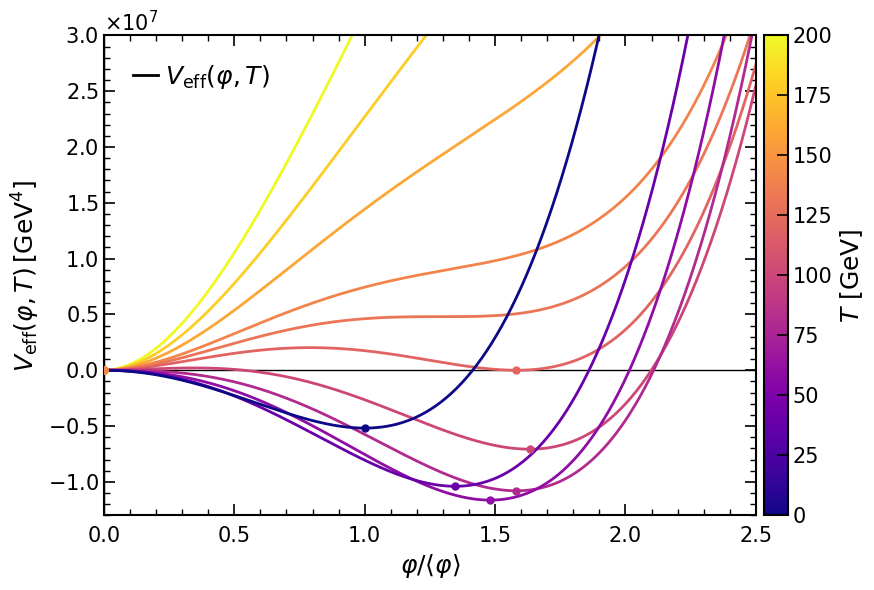

In [141]:
phi_vals = np.linspace(-50,300, 1000)
T_vals   = np.array([200., 180., 160., T1, 140., 120., 100.,  80.,  60.,  40.,   0.])

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=T_vals.min(), vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    color = cmap(norm(T))
    Veff  = V(phi_vals, T)
    ax.plot(phi_vals/v0, Veff, label=r'$V_{\mathrm{eff}}(\varphi , T)$', color=color, lw=2, ls='-')

    mask = phi_vals > 0
    idx  = np.argmin(Veff[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = Veff[mask][idx]
    ax.plot(phi_min/v0, V_min, 'o', color=color, ms=5, zorder=10)

ax.set_xlim(0, 2.5)
ax.set_ylim(-1.3e7, 3e7)

ax.set_xlabel(r'$\varphi / \langle\varphi\rangle$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi, T) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=8)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

handles_list = [mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=1, label=r"$V_{\mathrm{eff}}(\varphi , T)$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"FOPT.pdf", format="pdf", bbox_inches="tight")
plt.show()

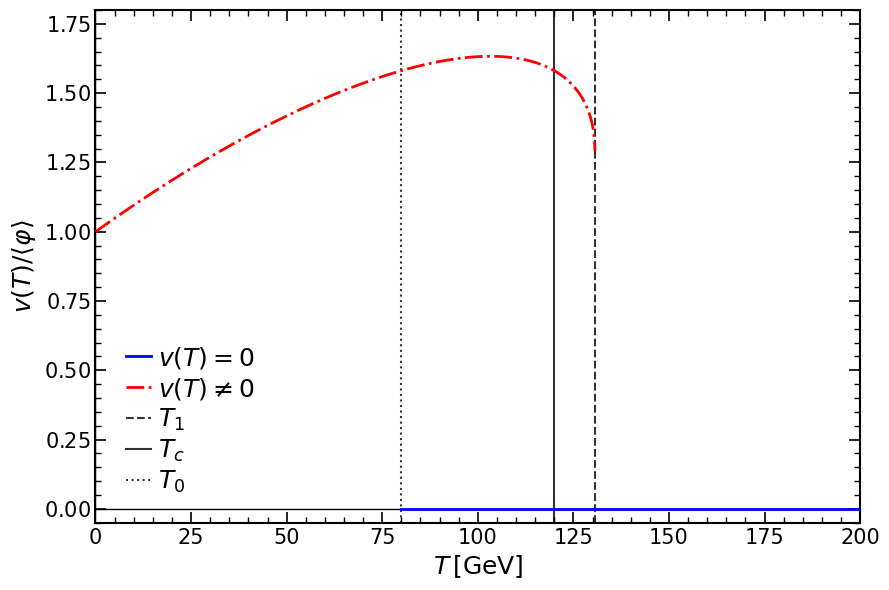

In [32]:
T_sym = np.linspace(T0, 300, 1000)
T_broken = np.linspace(0, T1, 1000)
T_list = np.linspace(0,300,1000)

v_sym = vev(T_sym)
v_broken = vev(T_broken)
v = vev(T_list)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(T_sym, np.zeros_like(T_sym), label=r'$v(T)=0$', color='b', lw=2, ls='-', zorder=10)
ax.plot(T_broken, v_broken/vev(0), label=r'$v(T)\neq 0$', color='r', lw=2, ls='-.', zorder=10)
ax.axvline(T1, label=r'$T_1$', color='k', lw=1.5, ls='--', alpha=0.8)
ax.axvline(Tc, label=r'$T_c$', color='k', lw=1.5, ls='-', alpha=0.8)
ax.axvline(T0, label=r'$T_0$', color='k', lw=1.5, ls=':', alpha=0.8)

ax.set_xlim(0, 200)
ax.set_ylim(-0.05, 1.8)

ax.set_xlabel(r'$T \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$v(T)/\langle\varphi\rangle$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
#ax.tick_params(axis='x', which='major', pad=8)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"FOPT_VEV.pdf", format="pdf", bbox_inches="tight")
plt.show()